# Homework 7

## Your Name Here (or your names here if you are pair programming)

Student Name: Kyle Castillo

Student UT EID: kmc5794

---

Partner Name: Andre Sae

Partner UT EID: as226576

---

Date Created: 10/22/2025

Date Last Modified:

---

Totoal Points 20. 



## Supprt Vector Machine 

In [2]:
# Standard Headers
# You are welcome to add additional headers here if you wish
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Enable inline mode for matplotlib so that Jupyter displays graphs
%matplotlib inline

# Your allowed to use only the above libraries that are imported. No other libs should be used in this assignment. 

## Heart Dataset 

In this Assignment we will work with some patients dataset. 

We have access to 303 patients data. The features are listed below. 

In [3]:
# Your code here
heart_df = pd.read_csv("Heart.csv")
heart_df

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,Target
0,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


**Age:** The person’s age in years

**Sex:** The person’s sex (1 = male, 0 = female)

**ChestPain:** chest pain type

* Value 0: asymptomatic
* Value 1: atypical angina
* Value 2: non-anginal pain
* Value 3: typical angina

**RestBP:** The person’s resting blood pressure (mm Hg on admission to the hospital)

**Chol:** The person’s cholesterol measurement in mg/dl

**Fbs:** The person’s fasting blood sugar (> 120 mg/dl, 1 = true; 0 = false)
restecg: resting electrocardiographic results

* Value 0: showing probable or definite left ventricular hypertrophy by Estes’ criteria
* Value 1: normal
* Value 2: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)

**RestECG:** The person’s maximum heart rate achieved

**MaxHR:** Exercise induced angina (1 = yes; 0 = no)

**Oldpeak:** ST depression induced by exercise relative to rest (‘ST’ relates to positions on the ECG plot. See more here)

**Slope:** the slope of the peak exercise ST segment — 0: downsloping; 1: flat; 2: upsloping

* 0: downsloping; 
* 1: flat; 
* 2: upsloping

**Ca:** The number of major vessels (0–3)

**Thal:** A blood disorder called thalassemia Value 0: NULL (dropped from the dataset previously

* Value 1: fixed defect (no blood flow in some part of the heart)
* Value 2: normal blood flow
* Value 3: reversible defect (a blood flow is observed but it is not normal)

**Target:** Heart disease (1 = no, 0= yes)

# Task - 1 Implement SVM using libraries (4 points)
We want to use **Suppert Vector Machine** to perdict if the patients will have heart problems or not. The column "Target" in our datasets includes data about heart diseases. If the patient had heart disease we have a 1 and if not a zero. 

Prepare your data set for predicting heart disease ("Target" column) out of 3 features:

* Age of the patient (Column **"Age"**)
* Gender of the patient (male or female - Column **"Sex"**)
* Cholestrol level of the patient (Column **"Chol"**) 


Split your data into 80% traning data and 20% test data, and implement Support Vector Machine using Scikit-Learn. 





In [85]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler((-1, 1))

features = heart_df[["Age", "Sex", "Chol"]]
# features["Age"] = features["Age"] - features["Age"].mean()
features['Age'] = scaler.fit_transform(features["Age"].to_frame())
features["Sex"] = (features["Sex"] * 2 ) - 1
# features["Chol"] = features["Chol"] - features["Chol"].mean()
features['Chol'] = scaler.fit_transform(features["Chol"].to_frame())

# features = pd.DataFrame(scaler.fit_transform(features))

print(features)

labels = (heart_df["Target"] == "Yes").astype(int)
labels = (labels * 2 ) - 1
# train/test split
split = 0.8

train = np.arange(0, round(features.shape[0] * split) + 1)
test = np.arange(train[-1] + 1, features.shape[0])

train_x = features.iloc[train]
train_y = labels.iloc[train]

test_x = features.iloc[test]
test_y = labels.iloc[test]

          Age  Sex      Chol
0    0.416667    1 -0.511416
1    0.583333    1 -0.269406
2    0.583333    1 -0.529680
3   -0.666667    1 -0.433790
4   -0.500000   -1 -0.643836
..        ...  ...       ...
298 -0.333333    1 -0.369863
299  0.625000    1 -0.694064
300  0.166667    1 -0.977169
301  0.166667   -1 -0.497717
302 -0.625000    1 -0.776256

[303 rows x 3 columns]


/tmp/ipykernel_331066/1164932294.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features['Age'] = scaler.fit_transform(features["Age"].to_frame())
/tmp/ipykernel_331066/1164932294.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Sex"] = (features["Sex"] * 2 ) - 1
/tmp/ipykernel_331066/1164932294.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [86]:
from sklearn import svm  # type: ignore

svm_ = svm.SVC()
trained_svm = svm_.fit(train_x, train_y)
y_pred = trained_svm.predict(test_x)

# Task 2 - (4 points)

Cacluate the accuracy, Precision, Recall and F1 score of your **SVM** implementaion from Task 1. 
Print the results. 

You may use library methods for this task if you choose to.


In [87]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix = confusion_matrix(test_y, y_pred)
class_report = classification_report(test_y, y_pred)

print(f"confusion matrix:\n{conf_matrix}\n")
print(f"classification report:\n{class_report}")

confusion matrix:
[[20  8]
 [17 15]]

classification report:
              precision    recall  f1-score   support

          -1       0.54      0.71      0.62        28
           1       0.65      0.47      0.55        32

    accuracy                           0.58        60
   macro avg       0.60      0.59      0.58        60
weighted avg       0.60      0.58      0.58        60



# Task 3 - Implement SVM without using libraries  - (4 points)

Implement SVM from scratch using Hinge Loss function and Gradient Descent. 
Try to produce the same result as you get from the libraries. 


* Do as many iterations as needed 
* Do maximum **100 iterations**
* Use a very small learning rate for checking your GD implementation. 
* Your are allowed to use your choice of learning rate, like using 0.0001, 0.001 or 0.01 or 0.1 or higher. 
* Visualize your costs. 
* No need to add an y-intercept in this task. 
* You can use libraries to report accuracy, Precision, Recall and F1. 



[1.14492724 0.86128961 0.99499313]


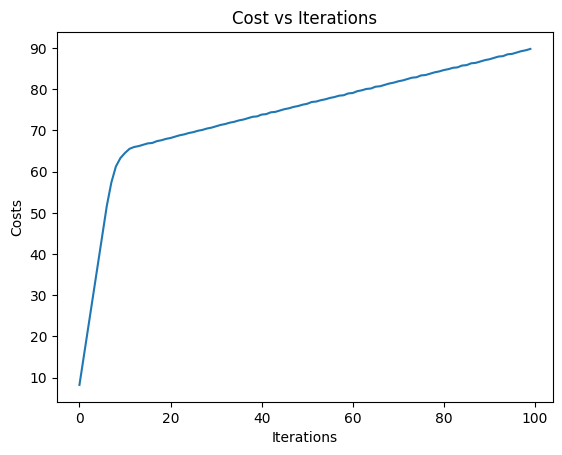

Accuracy Score: 0.6833333333333333
Precision Score: 0.6857142857142857
Recall Score: 0.75
F1 Score: 0.7164179104477612


In [126]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

l_rate = 0.002

# initalized weight without bias term (since no y intercept term)
weights = np.zeros(shape=(len(features.columns)))
c = 1
costs = []

# NOT CORRECT: ASSUMPTION: feed in misclassified point
def loss_fn(x, y, w):
    
    lamb = 1 / (len(y) * c)
    # print(np.maximum(np.zeros(shape=(len(y))), 1 - np.dot(- 1 * y, np.matmul(x, w))))
    return ( lamb / 2 ) * np.linalg.norm(w) ** 2 + (1 / len(y)) * np.sum(np.maximum(np.zeros(shape=(len(y))), 1 - np.dot(- 1 * y, np.matmul(x, w))))

# NOT CORRECT: ASSUMPTION: feed in misclassified point
# expected shape is a scalar in this
def grad_loss_fn(x, y, w):
    # print(np.dot(np.ones(shape=(len(x[0]), 1)), y.reshape(1, len(y)))[0])

    lamb = 1 / (len(y) * c)
    reg = ( lamb ) * w

    hinge = np.zeros(shape=w.shape)

    for i in range(0, len(y)):
        x_i = x[i]
        y_i = y[i]

        if 1 - y_i * np.dot(w, x_i) < 0:
            continue
        else:
            hinge += - y_i * x_i

    return reg + hinge


def train_svm(x_train, y_train, w_0, l_rate, cost_list):
    w = w_0
    
    for i in range(0, 100):
        y_pred = np.dot(w.reshape((1, len(w))), x_train.T)[0]

        w = w - l_rate * grad_loss_fn(x_train, y_train, w)

        cost = loss_fn(x_train, y_train, w)
        cost_list.append(cost)

    return w

def predict_svm(x_test, w):
    y = np.matmul(x_test, w)
    y[y < 0] = -1 
    y[y > 0] = 1
    return y

w_f = train_svm(train_x.to_numpy(), train_y.to_numpy(), weights, l_rate, costs)

print(w_f)

test_pred_y =  predict_svm(test_x, w_f)

plt.plot(range(0, len(costs)), costs)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Costs")
plt.show()

print("Accuracy Score: " + str(accuracy_score(test_y, test_pred_y)))
print("Precision Score: " + str(precision_score(test_y, test_pred_y)))
print("Recall Score: " + str(recall_score(test_y, test_pred_y)))
print("F1 Score: " + str(f1_score(test_y, test_pred_y)))
    


# Task 4 - Compare SVM results with Logistic Regression - (4 points)

Which model performs better here? Compare your results wit the logistic regression. You can use libraries for this task, it is not necessary to implement logistic regression from sratch.


In [114]:
# Add your code Here!

from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(train_x, train_y)

y_pred = model.predict(test_x)

print("Accuracy Score: " + str(accuracy_score(test_y, y_pred)))
print("Precision Score: " + str(precision_score(test_y, y_pred)))
print("Recall Score: " + str(recall_score(test_y, y_pred)))
print("F1 Score: " + str(f1_score(test_y, y_pred)))

Accuracy Score: 0.6
Precision Score: 0.6538461538461539
Recall Score: 0.53125
F1 Score: 0.5862068965517241


The default sklearn SVM and logistic regression perform very similarly. However, our custom SVM implementation performs much more robustly in terms of all metrics including accuracy score, precision score, recall score, and F1 score. 

# Task 5 - Apply a kernel function to improve SVM performance (4 points)

Use the Scikit-learn librariy and apply a kernel function to improve the SVM performance. Check if this is possible. 


In [125]:
# Add your code Here!

from sklearn.svm import SVC 

model = SVC(kernel='sigmoid')

model.fit(train_x, train_y)

y_pred = model.predict(test_x)

print("Accuracy Score: " + str(accuracy_score(test_y, y_pred)))
print("Precision Score: " + str(precision_score(test_y, y_pred)))
print("Recall Score: " + str(recall_score(test_y, y_pred)))
print("F1 Score: " + str(f1_score(test_y, y_pred)))

Accuracy Score: 0.6
Precision Score: 0.625
Recall Score: 0.625
F1 Score: 0.625


There is a slight improvement to the default SVM by using the kernel function to seperate the data. 